In [33]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Reading the dataset
data = pd.read_csv('transaction_dataset.csv')

# Display the first few rows of the data to inspect it
print("Initial Data Preview:")
print(data.head())

Initial Data Preview:
  TransactionID CustomerID  ProductID ProductName  Quantity  PriceperUnit  \
0     TXN000001   CUST9935        4.0       Bread       1.0         175.0   
1     TXN000002   CUST2424        1.0       Pasta      14.0         121.0   
2     TXN000003   CUST7912        8.0       Pasta       9.0         102.0   
3     TXN000004   CUST1520        8.0      Yogurt       5.0         164.0   
4     TXN000005   CUST1488       10.0      Yogurt      20.0         175.0   

         Date    Region  
0    1/3/2023     Galle  
1    1/4/2023     Galle  
2   3/16/2024  Kalutara  
3  10/11/2024  Kalutara  
4    5/8/2024    Matara  


In [34]:
# Convert the 'Date' column to datetime type
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# Create a new column 'TotalPrice' that computes the revenue for each transaction
data['TotalPrice'] = data['Quantity'] * data['PriceperUnit']

# Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())

# Optional: Drop duplicates if any
data.drop_duplicates(inplace=True)

# Optional: Fill or drop missing values if necessary (example: drop rows with missing dates)
data = data.dropna(subset=['Date'])

print("\nData after pre-processing:")
print(data.head())


Missing values per column:
TransactionID    14
CustomerID       19
ProductID        15
ProductName      21
Quantity         26
PriceperUnit     28
Date             29
Region           18
TotalPrice       31
dtype: int64

Data after pre-processing:
  TransactionID CustomerID  ProductID ProductName  Quantity  PriceperUnit  \
0     TXN000001   CUST9935        4.0       Bread       1.0         175.0   
1     TXN000002   CUST2424        1.0       Pasta      14.0         121.0   
2     TXN000003   CUST7912        8.0       Pasta       9.0         102.0   
3     TXN000004   CUST1520        8.0      Yogurt       5.0         164.0   
4     TXN000005   CUST1488       10.0      Yogurt      20.0         175.0   

        Date    Region  TotalPrice  
0 2023-01-03     Galle       175.0  
1 2023-01-04     Galle      1694.0  
2 2024-03-16  Kalutara       918.0  
3 2024-10-11  Kalutara       820.0  
4 2024-05-08    Matara      3500.0  


Top 10 Best-Selling Products:
  ProductName  Quantity
0       Apple   53562.0
6        Milk   53337.0
8        Rice   53220.0
9      Yogurt   53044.0
4      Coffee   52783.0
3     Chicken   52660.0
2      Cheese   51689.0
7       Pasta   51617.0
5        Fish   51199.0
1       Bread   50727.0


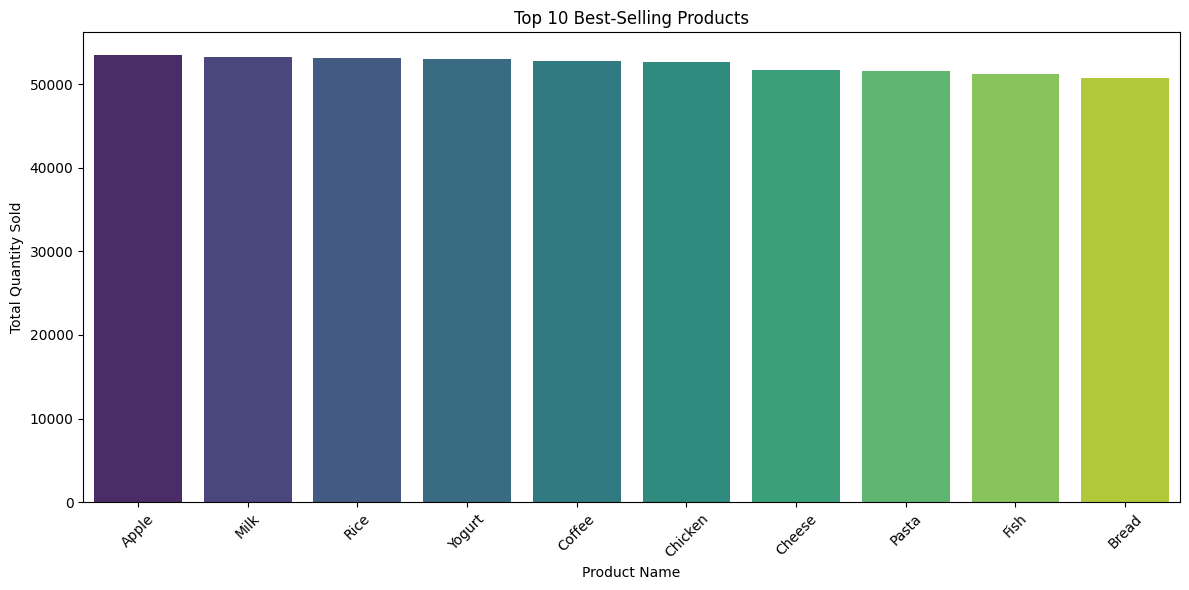

In [35]:
# Group by ProductName and sum the Quantity sold
best_selling = data.groupby('ProductName')['Quantity'].sum().reset_index()

# Sort the results in descending order of quantity sold
best_selling = best_selling.sort_values(by='Quantity', ascending=False)

# Display the top 10 best-selling products
print("Top 10 Best-Selling Products:")
print(best_selling.head(10))

# Plot the best-selling products
plt.figure(figsize=(12,6))
sns.barplot(data=best_selling.head(10), x='ProductName', y='Quantity', palette="viridis")
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


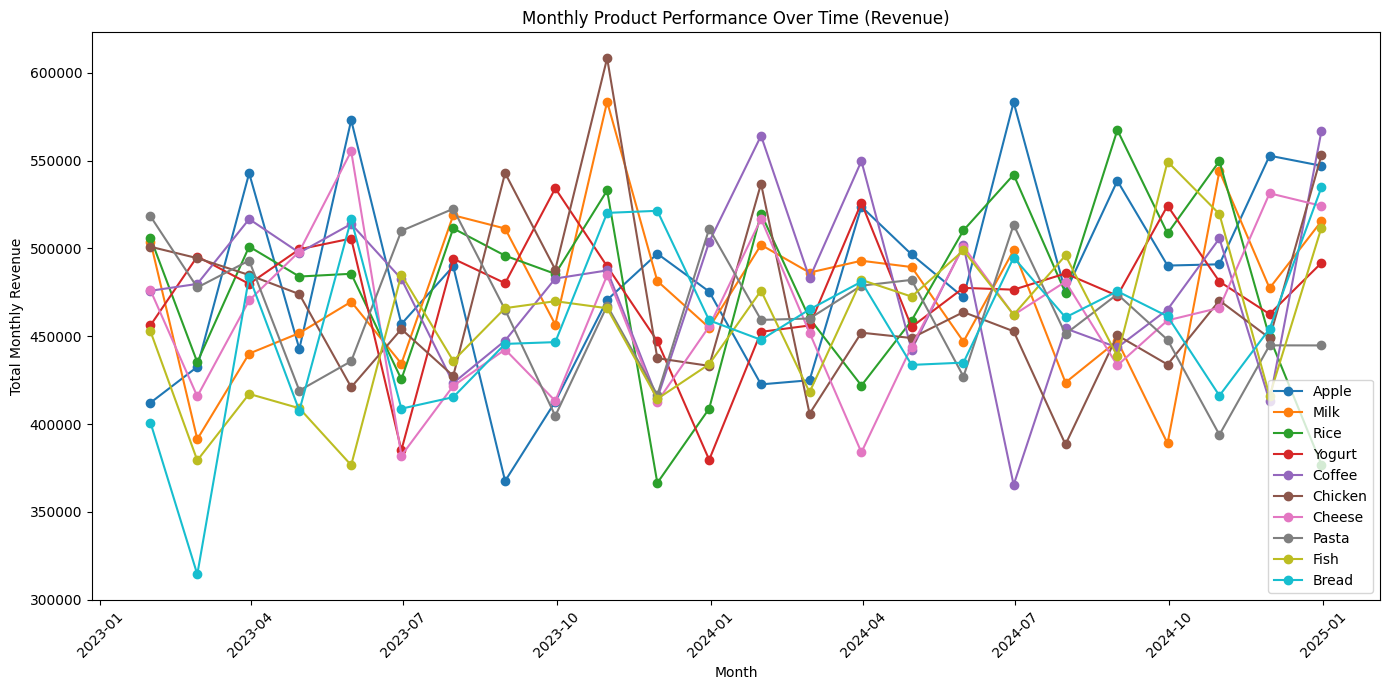

In [41]:

# Aggregate to monthly revenue
monthly_performance = data.groupby(['ProductName', pd.Grouper(key='Date', freq='M')])['TotalPrice'].sum().reset_index()
top_products = best_selling.head(10)['ProductName'].tolist()
monthly_performance_subset = monthly_performance[monthly_performance['ProductName'].isin(top_products)]

# Plotting monthly product performance
plt.figure(figsize=(14, 7))
for product in top_products:
    subset = monthly_performance_subset[monthly_performance_subset['ProductName'] == product]
    plt.plot(subset['Date'], subset['TotalPrice'], marker='o', label=product)

plt.title("Monthly Product Performance Over Time (Revenue)")
plt.xlabel("Month")
plt.ylabel("Total Monthly Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monthly Sales Trends:
        Date  TotalPrice
0 2023-01-31   4703076.0
1 2023-02-28   4315806.0
2 2023-03-31   4829649.0
3 2023-04-30   4583335.0
4 2023-05-31   4852825.0


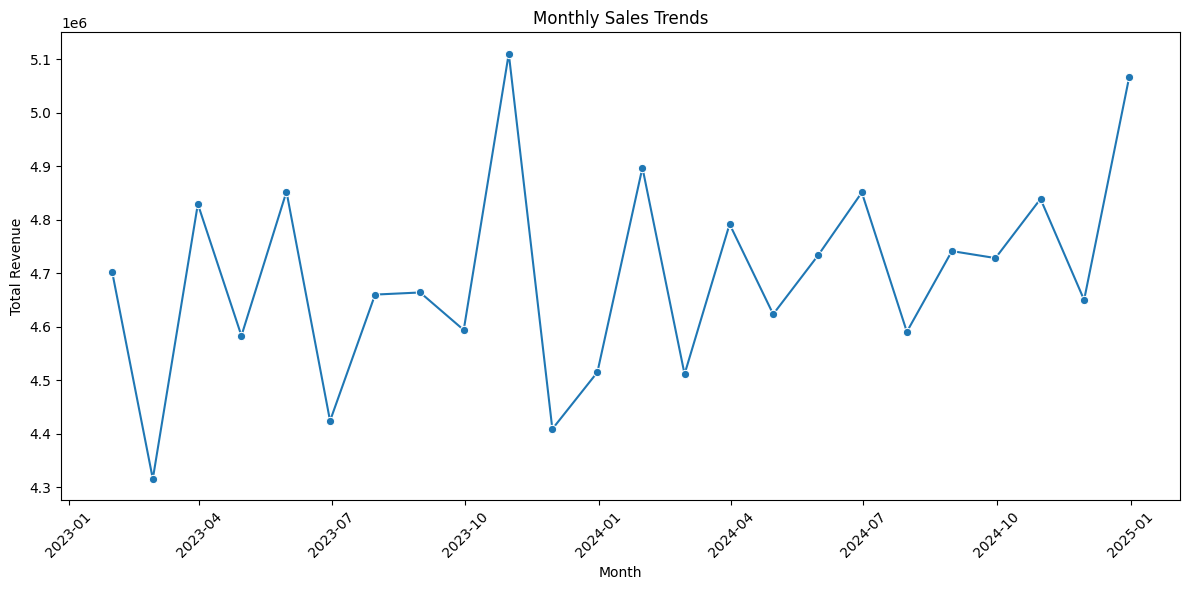

In [42]:
# Set Date as index (if not already) for time series operations
data.set_index('Date', inplace=True)

# Resample the data by month and sum the TotalPrice to compute monthly sales
monthly_sales = data['TotalPrice'].resample('M').sum().reset_index()

print("Monthly Sales Trends:")
print(monthly_sales.head())

# Plot the sales trends
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Date', y='TotalPrice', marker='o')
plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Reset index for future analysis
data.reset_index(inplace=True)


Customer Behaviour Analysis (Sample):
  CustomerID  TotalItemsPurchased  TotalSpent
0   CUST1000                 57.0     17764.0
1   CUST1001                 41.0      4919.0
2   CUST1002                 36.0      4640.0
3   CUST1003                 44.0     10344.0
4   CUST1004                 37.0     12693.0


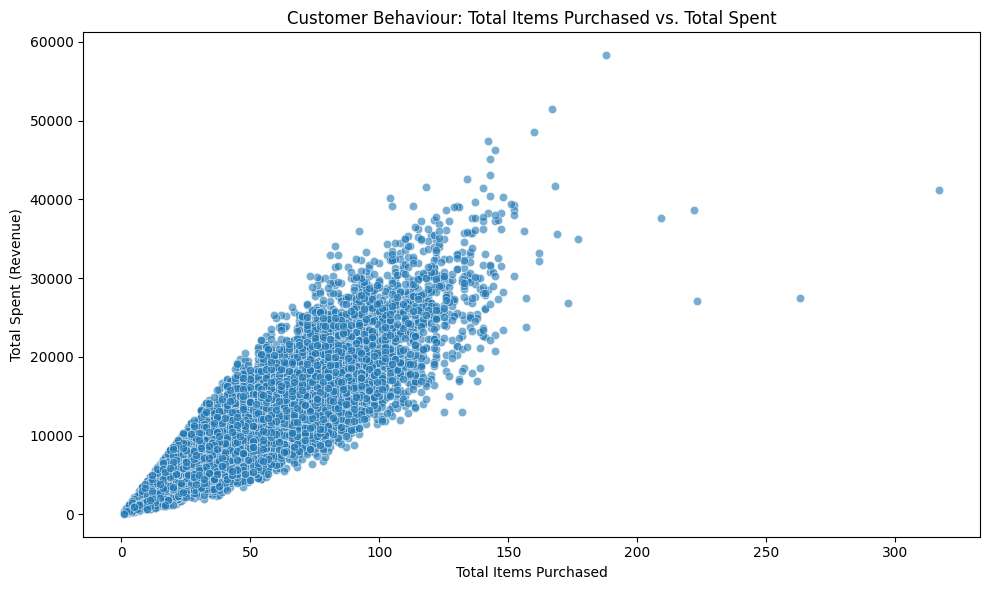

In [43]:
# Group by CustomerID to compute the total number of items purchased and total revenue per customer
customer_behaviour = data.groupby('CustomerID').agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).reset_index()

# Rename the columns for clarity
customer_behaviour.rename(columns={'Quantity': 'TotalItemsPurchased', 'TotalPrice': 'TotalSpent'}, inplace=True)

# Display sample customer behavior data
print("Customer Behaviour Analysis (Sample):")
print(customer_behaviour.head())

# Plot a scatter plot to visualize customer spending vs. number of items purchased
plt.figure(figsize=(10,6))
sns.scatterplot(data=customer_behaviour, x='TotalItemsPurchased', y='TotalSpent', alpha=0.6)
plt.title("Customer Behaviour: Total Items Purchased vs. Total Spent")
plt.xlabel("Total Items Purchased")
plt.ylabel("Total Spent (Revenue)")
plt.tight_layout()
plt.show()


Regional Sales Analysis:
     Region  TotalPrice
2  Kalutara  28491120.0
0   Colombo  28286810.0
3    Matara  28005441.0
1     Galle  27901262.0


<function matplotlib.pyplot.ylabel(ylabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)>

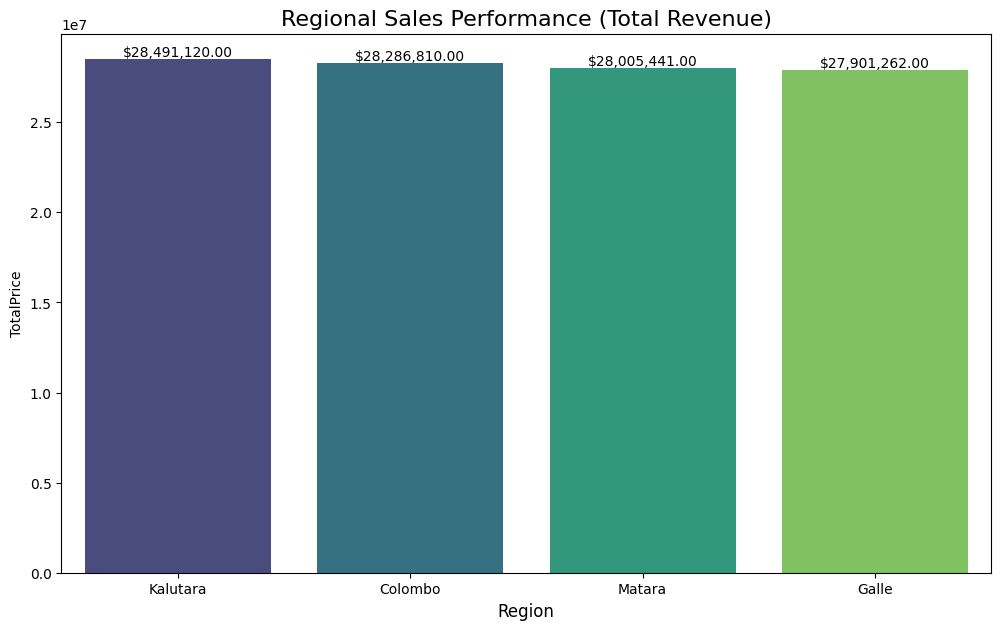

In [56]:
# Group by Region and calculate the total revenue
regional_sales = data.groupby('Region')['TotalPrice'].sum().reset_index()

# Sort the results in descending order of revenue
regional_sales = regional_sales.sort_values(by='TotalPrice', ascending=False)

print("Regional Sales Analysis:")
print(regional_sales)

# 1. Improved Aesthetics and Readability
plt.figure(figsize=(12, 7))  # Adjust figure size for better visibility
sns.barplot(data=regional_sales, x='Region', y='TotalPrice', palette="viridis") # Use a more informative and visually appealing palette

# Add value labels on the bars for direct comparison
for index, value in enumerate(regional_sales['TotalPrice']):
    plt.text(index, value, f"${value:,.2f}", ha='center', va='bottom')

plt.title("Regional Sales Performance (Total Revenue)", fontsize=16) # More descriptive title with larger font
plt.xlabel("Region", fontsize=12)
plt.ylabel